In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)

print("GPU available:")
print(tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available:
[]


In [16]:
DATASET_DIR = "/content/drive/MyDrive/braintumor"

TRAIN_DIR = os.path.join(DATASET_DIR, "Training")
TEST_DIR = os.path.join(DATASET_DIR, "Testing")

print("Dataset directory:", DATASET_DIR)
print("Training directory:", TRAIN_DIR)
print("Testing directory:", TEST_DIR)

Dataset directory: /content/drive/MyDrive/braintumor
Training directory: /content/drive/MyDrive/braintumor/Training
Testing directory: /content/drive/MyDrive/braintumor/Testing


In [17]:
print("Main dataset:")
print(os.listdir(DATASET_DIR))

print("\nTraining classes:")
print(os.listdir(TRAIN_DIR))

print("\nTesting classes:")
print(os.listdir(TEST_DIR))

Main dataset:
['Testing', 'Training']

Training classes:
['meningioma_tumor', 'no_tumor', 'pituitary_tumor', 'glioma_tumor']

Testing classes:
['glioma_tumor', 'no_tumor', 'pituitary_tumor', 'meningioma_tumor']


In [18]:
def count_images(directory):
    extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

    total = 0

    for root, dirs, files in os.walk(directory):
        count = sum(
            1 for file in files
            if file.lower().endswith(extensions)
        )

        if count > 0:
            print(root, ":", count)

        total += count

    return total


print("TRAINING DATA")
print("=" * 50)

train_count = count_images(TRAIN_DIR)

print("\nTotal training images:", train_count)


print("\nTESTING DATA")
print("=" * 50)

test_count = count_images(TEST_DIR)

print("\nTotal testing images:", test_count)

TRAINING DATA
/content/drive/MyDrive/braintumor/Training/meningioma_tumor : 822
/content/drive/MyDrive/braintumor/Training/no_tumor : 395
/content/drive/MyDrive/braintumor/Training/pituitary_tumor : 827
/content/drive/MyDrive/braintumor/Training/glioma_tumor : 826

Total training images: 2870

TESTING DATA
/content/drive/MyDrive/braintumor/Testing/glioma_tumor : 100
/content/drive/MyDrive/braintumor/Testing/no_tumor : 105
/content/drive/MyDrive/braintumor/Testing/pituitary_tumor : 74
/content/drive/MyDrive/braintumor/Testing/meningioma_tumor : 115

Total testing images: 394


In [19]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [20]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 2870 files belonging to 4 classes.
Using 2296 files for training.


In [21]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 2870 files belonging to 4 classes.
Using 574 files for validation.


In [22]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 394 files belonging to 4 classes.


In [23]:
class_names = train_ds.class_names

NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Number of classes: 4


In [24]:
print("Training classes:")
print(train_ds.class_names)

print("\nTesting classes:")
print(test_ds.class_names)

Training classes:
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

Testing classes:
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [25]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

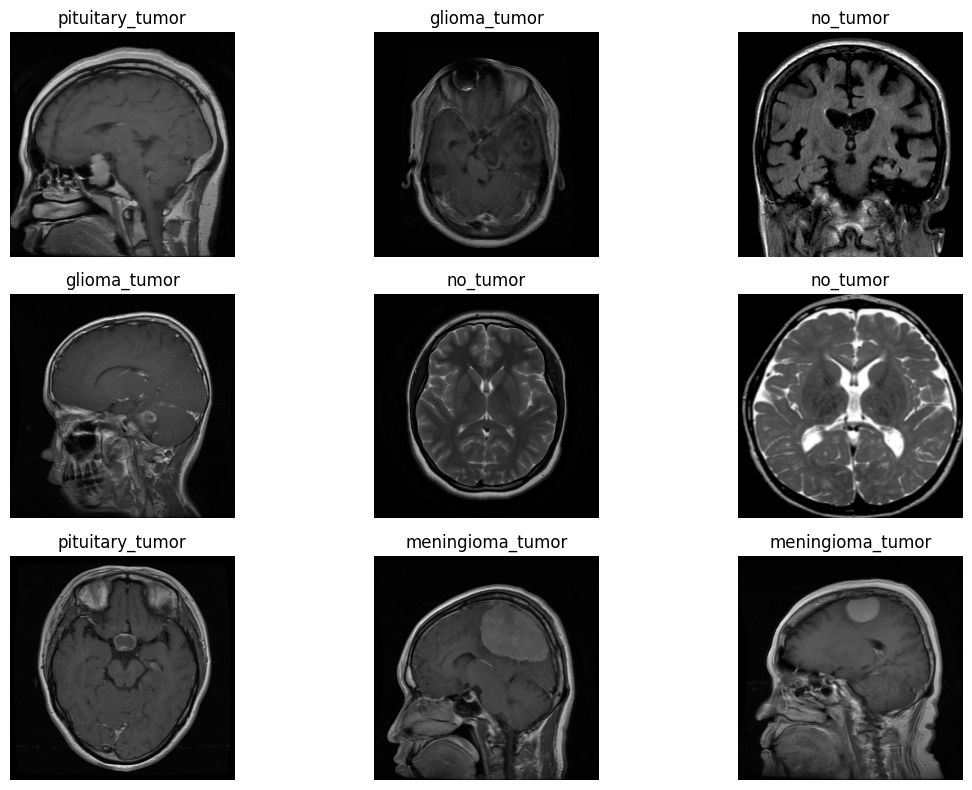

In [26]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
], name="data_augmentation")

In [28]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

print("EfficientNetB0 loaded successfully.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 loaded successfully.


In [29]:
base_model.trainable = False

print("Trainable:", base_model.trainable)

Trainable: False


In [30]:
inputs = keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# Pretrained EfficientNet
x = base_model(x, training=False)

# Convert feature maps into a feature vector
x = layers.GlobalAveragePooling2D()(x)

# Reduce overfitting
x = layers.Dropout(0.3)(x)

# Classification layer
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [31]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [32]:
checkpoint_path = "/content/drive/MyDrive/brain_tumor_efficientnet_best.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [33]:
INITIAL_EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4600 - loss: 1.2189
Epoch 1: val_accuracy improved from None to 0.67247, saving model to /content/drive/MyDrive/brain_tumor_efficientnet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_efficientnet_best.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 390s 5s/step - accuracy: 0.5767 - loss: 1.0220 - val_accuracy: 0.6725 - val_loss: 0.7971 - learning_rate: 0.0010
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7086 - loss: 0.7504
Epoch 2: val_accuracy improved from 0.67247 to 0.69686, saving model to /content/drive/MyDrive/brain_tumor_efficientnet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/brain_tumor_efficientnet_best.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.7243 - loss: 0.7117 - val_accuracy: 0.6969 - val_loss: 0.7157 - learning_rate: 0.0010
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7459 - loss: 0.6469
Epoch 3: val_accuracy im

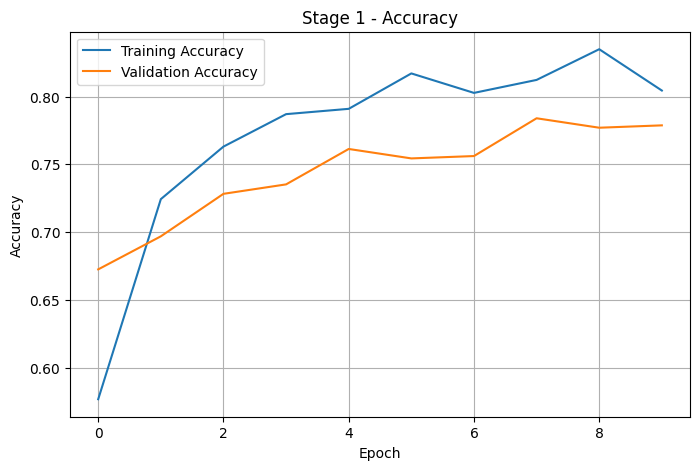

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Stage 1 - Accuracy")

plt.legend()
plt.grid(True)

plt.show()

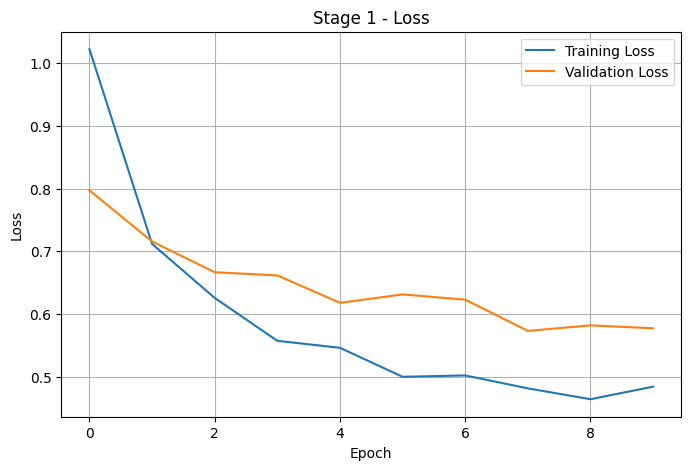

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 1 - Loss")

plt.legend()
plt.grid(True)

plt.show()